In [1]:
import pandas as pd

# 1. Load the raw data dictionary
raw_data = {
    "Player": ["Luke Shaw", "Bruno Fernandes", "Diogo Dalot", "Casemiro", "Bryan Mbeumo", "Matheus Cunha", "Amad Diallo", "Leny Yoro", "Benjamin Šeško", "Kobbie Mainoo", "Patrick Dorgu", "Mason Mount", "Harry Maguire", "Noussair Mazraoui", "Lisandro Martínez", "Ayden Heaven", "Matthijs de Ligt", "Manuel Ugarte"],
    "Position": ["DF", "MF", "DF", "MF", "FW", "FW", "MF", "DF", "FW", "MF", "MF", "MF", "DF", "DF", "DF", "DF", "DF", "MF"],
    "Matches_Played": [38, 35, 34, 34, 33, 33, 32, 32, 30, 28, 26, 23, 23, 20, 18, 17, 13, 22],
    "Starts": [38, 35, 29, 33, 31, 29, 27, 18, 17, 16, 15, 12, 19, 11, 13, 11, 13, 8],
    "Minutes": [3219, 3063, 2614, 2571, 2609, 2494, 2341, 1740, 1643, 1662, 1449, 1017, 1653, 985, 1233, 924, 1170, 1010],
    "Goals": [1, 9, 1, 9, 11, 10, 2, 0, 11, 1, 4, 3, 1, 0, 0, 0, 1, 0],
    "Assists": [1, 21, 3, 2, 3, 2, 3, 0, 1, 2, 4, 0, 2, 0, 0, 1, 0, 0]
}

df = pd.DataFrame(raw_data)

# 2. FEATURE ENGINEERING: Calculate Goals + Assists Per 90 Minutes
# (Minutes / 90 gives the total number of full games played)
df['G_A'] = df['Goals'] + df['Assists']
df['G_A_per_90'] = (df['G_A'] / (df['Minutes'] / 90)).round(2)

# 3. ANALYSIS: Filter out low-minute samples to avoid skewed outliers
# We only want players who played more than 500 total minutes.
reliable_players = df[df['Minutes'] > 500]

# 4. FINDING THE MOST EFFICIENT ATTACKER
top_efficient = reliable_players.sort_values(by='G_A_per_90', ascending=False)
print(top_efficient[['Player', 'Position', 'G_A', 'G_A_per_90']].head(5))


             Player Position  G_A  G_A_per_90
1   Bruno Fernandes       MF   30        0.88
8    Benjamin Šeško       FW   12        0.66
10    Patrick Dorgu       MF    8        0.50
4      Bryan Mbeumo       FW   14        0.48
5     Matheus Cunha       FW   12        0.43


/tmp/ipykernel_2123/4214211338.py:36: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


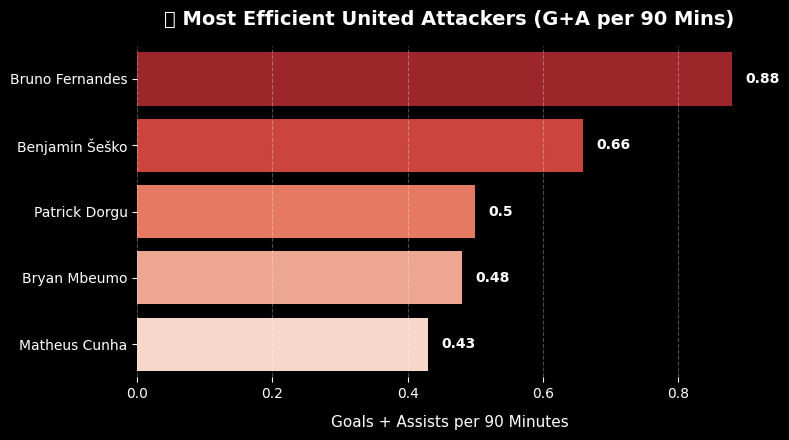

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean, modern dark style for the chart
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(8, 4.5))

# Get our top 5 most efficient players from your previous variable
top_5 = top_efficient.head(5)

# Create the horizontal bar plot cleanly without library warnings
sns.barplot(
    x='G_A_per_90',
    y='Player',
    data=top_5,
    hue='Player',      # Assigning the hue explicitly silences the warning
    legend=False,      # Removes the unneeded legend box
    palette='Reds_r',
    ax=ax
)


# Customize the text and design labels
ax.set_title("🔥 Most Efficient United Attackers (G+A per 90 Mins)", fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Goals + Assists per 90 Minutes", fontsize=11, labelpad=10)
ax.set_ylabel("", fontsize=11)

# Clean up the borders
sns.despine(left=True, bottom=True)
ax.grid(axis='x', linestyle='--', alpha=0.3)

# Add value tags to the end of each bar dynamically
for index, value in enumerate(top_5['G_A_per_90']):
    ax.text(value + 0.02, index, f"{value}", va='center', fontweight='bold', color='white')

plt.tight_layout()
plt.show()
